# 74 - Qwen2.5-VL-7B 多言語キャプション生成

## 概要
本シリーズ最重要ノートブック。Qwen2.5-VL-7B-Instruct を使い、
初めて**日本語と英語の両方**で高品質なキャプションを生成する。
Notebook 72 (BLIP-2) / 73 (Florence-2) は英語のみだったが、本ノートブックで日本語キャプションの品質を本格評価する。

## Qwen2.5-VL の特徴
- **Qwen2.5-VL**: Alibaba の視覚言語モデル（7B パラメータ）
- **多言語対応**: 英語、中国語、日本語、韓国語など多言語に対応
- **動的解像度**: ナイーブ動的解像度（画像サイズに応じてトークン数を調整）
- **VRAM**: ~15GB (fp16)

## 評価
- Self-Retrieval Score（SigLIP 2 Large でキャプションをembed → 画像embeddingとの類似度）
- CLIPScore（CLIP-L による画像-テキスト整合性スコア）
- 日英キャプション間のクロスリンガル一貫性
- カテゴリ別・言語別の品質比較
- BLIP-2 / Florence-2 との比較

## 使用モデル
- キャプション生成: `Qwen/Qwen2.5-VL-7B-Instruct` (~15GB fp16)
- 評価: SigLIP 2 Large, CLIP-L

## 新規依存
- `qwen-vl-utils`: Qwen2.5-VL の画像前処理ユーティリティ

In [1]:
import json
import time
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image
from tqdm.notebook import tqdm
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor

## 1. 設定とデータ読み込み

In [2]:
DB_PATH = Path("../data/images.duckdb")
QWEN_MODEL = "Qwen/Qwen2.5-VL-7B-Instruct"
SIGLIP2_MODEL = "google/siglip2-large-patch16-256"

# 画像カタログの読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)

catalog_df = conn.execute("""
    SELECT id, file_path, category, file_name
    FROM image_catalog
    ORDER BY id
""").fetchdf()

# SigLIP 2 Large の画像埋め込みを読み込み（評価用）
embeddings_df = conn.execute("""
    SELECT c.id, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [SIGLIP2_MODEL]).fetchdf()
conn.close()

image_embeddings = np.array(embeddings_df['embedding'].tolist(), dtype=np.float32)
norms = np.linalg.norm(image_embeddings, axis=1, keepdims=True)
image_embeddings_norm = image_embeddings / np.clip(norms, 1e-8, None)

print(f"Total images: {len(catalog_df)}")
print(f"Image embeddings: {image_embeddings.shape}")
print(f"\nCategories:")
for cat, count in catalog_df['category'].value_counts().items():
    print(f"  {cat}: {count}")

Total images: 378
Image embeddings: (378, 1024)

Categories:
  EuroPython2025: 129
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  KashiwaVillagePark2026: 56
  TokyoNight202505: 49
  terada: 10


## 2. Qwen2.5-VL モデルの読み込み

In [3]:
print(f"Loading Qwen2.5-VL model: {QWEN_MODEL}")
print("This may take several minutes for the first download (~15GB)...")

qwen_processor = AutoProcessor.from_pretrained(QWEN_MODEL)
qwen_model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    QWEN_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
)

print(f"Model loaded.")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")

Loading Qwen2.5-VL model: Qwen/Qwen2.5-VL-7B-Instruct
This may take several minutes for the first download (~15GB)...


The image processor of type `Qwen2VLImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Model loaded.
GPU memory allocated: 15.4 GB


In [4]:
def generate_caption_qwen(image: Image.Image, prompt: str, max_new_tokens: int = 256) -> str:
    """Qwen2.5-VL でキャプションを生成する。"""
    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": image},
                {"type": "text", "text": prompt},
            ],
        }
    ]
    
    text = qwen_processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = qwen_processor(
        text=[text],
        images=[image],
        padding=True,
        return_tensors="pt",
    ).to(qwen_model.device)
    
    with torch.no_grad():
        generated_ids = qwen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
        )
    
    # 入力トークンを除いた部分をデコード
    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    caption = qwen_processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )[0].strip()
    
    return caption

# テスト
test_img = Image.open(catalog_df.iloc[0]['file_path']).convert('RGB')
test_caption = generate_caption_qwen(test_img, "Describe this image in one sentence.")
print(f"Test (EN): {test_caption}")

test_caption_ja = generate_caption_qwen(test_img, "この画像を日本語で一文で説明してください。")
print(f"Test (JA): {test_caption_ja}")

Test (EN): The image shows a person wearing a red polo shirt with the logo of "Python Conference Japan" on it, standing against a light blue background.


Test (JA): 赤いシャツを着た男性が、Python Conference Japanのロゴが入ったポロシャツを着用しています。


## 3. 日英キャプション生成

4つのプロンプトで全画像のキャプションを生成する:
1. **英語・簡潔**: "Describe this image in one sentence."
2. **英語・詳細**: "Describe this image in detail."
3. **日本語・簡潔**: "この画像を日本語で一文で説明してください。"
4. **日本語・詳細**: "この画像を日本語で詳しく説明してください。"

In [5]:
prompt_configs = {
    "en_brief": "Describe this image in one sentence.",
    "en_detailed": "Describe this image in detail.",
    "ja_brief": "この画像を日本語で一文で説明してください。",
    "ja_detailed": "この画像を日本語で詳しく説明してください。",
}

all_captions = {key: [] for key in prompt_configs}

print(f"Generating captions for {len(catalog_df)} images x {len(prompt_configs)} prompts...")
start_time = time.time()

for idx in tqdm(range(len(catalog_df)), desc="Captioning"):
    row = catalog_df.iloc[idx]
    img = Image.open(row['file_path']).convert('RGB')
    
    for key, prompt in prompt_configs.items():
        caption = generate_caption_qwen(img, prompt)
        all_captions[key].append(caption)

elapsed = time.time() - start_time
print(f"\nTotal time: {elapsed:.1f}s ({elapsed/len(catalog_df):.2f}s per image)")
print(f"Speed: {len(catalog_df) / elapsed:.2f} images/sec (all prompts)")

Generating captions for 378 images x 4 prompts...


Captioning:   0%|          | 0/378 [00:00<?, ?it/s]


Total time: 11689.5s (30.92s per image)
Speed: 0.03 images/sec (all prompts)


In [6]:
# サンプルキャプション表示
print("=" * 80)
print("Sample Captions (Qwen2.5-VL)")
print("=" * 80)

for cat in catalog_df['category'].unique():
    cat_indices = catalog_df[catalog_df['category'] == cat].index.tolist()[:2]
    print(f"\n--- {cat} ---")
    for idx in cat_indices:
        print(f"  [{catalog_df.iloc[idx]['file_name']}]")
        for key in prompt_configs:
            cap = all_captions[key][idx]
            print(f"    {key:15s}: {cap[:120]}")
        print()

Sample Captions (Qwen2.5-VL)

--- terada ---
  [terada-202205-pyconjp-4-3-900.jpg]
    en_brief       : The image shows a person wearing a red polo shirt with the logo of "Python Conference Japan" on it, standing against a l
    en_detailed    : The image shows a person wearing a red polo shirt with a logo on the left side of the chest. The logo features a white c
    ja_brief       : 赤いシャツを着た男性が、Python Conference Japanのロゴが入ったポロシャツを着用しています。
    ja_detailed    : この画像には、赤いポロシャツを着た男性が写っています。シャツの左胸には「python Conference Japan」と書かれた白いラベルが付いており、Python言語に関するイベントやカンファレンスに関連していることを示唆しています。背

  [terada-uspycon2019-up.jpg]
    en_brief       : A person wearing a light blue shirt and a lanyard is standing at a podium with microphones, speaking in front of a color
    en_detailed    : The image shows a person standing at a podium, likely giving a speech or presentation. The individual is wearing a light
    ja_brief       : 青いシャツを着た男性が、黄色と緑の背景を持つステージでスピーチを行っている様子です。
    ja_detailed    : この画像には、青いシャツを

In [7]:
# キャプション統計
print("=" * 60)
print("Caption Statistics")
print("=" * 60)

for key in prompt_configs:
    captions = all_captions[key]
    # 文字数（日本語はスペース区切りでないので文字数で評価）
    char_lengths = [len(c) for c in captions]
    unique_ratio = len(set(captions)) / len(captions)
    print(f"\n{key}:")
    print(f"  Char count — Mean: {np.mean(char_lengths):.1f}, Std: {np.std(char_lengths):.1f}, "
          f"Min: {np.min(char_lengths)}, Max: {np.max(char_lengths)}")
    print(f"  Unique captions: {len(set(captions))} / {len(captions)} ({unique_ratio*100:.1f}%)")

Caption Statistics

en_brief:
  Char count — Mean: 144.6, Std: 29.4, Min: 72, Max: 270
  Unique captions: 372 / 378 (98.4%)

en_detailed:
  Char count — Mean: 1093.4, Std: 188.3, Min: 437, Max: 1394
  Unique captions: 377 / 378 (99.7%)

ja_brief:
  Char count — Mean: 35.4, Std: 13.7, Min: 13, Max: 101
  Unique captions: 359 / 378 (95.0%)

ja_detailed:
  Char count — Mean: 349.7, Std: 101.4, Min: 114, Max: 639
  Unique captions: 377 / 378 (99.7%)


## 4. Qwen2.5-VL のGPUメモリ解放 → 評価モデル読み込み

In [8]:
del qwen_model, qwen_processor
torch.cuda.empty_cache()
print("Qwen2.5-VL model released.")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")

Qwen2.5-VL model released.
GPU memory allocated: 0.0 GB


In [9]:
# SigLIP 2 Large で評価
from image_vector_poc import SigLIP2Embedder

embedder = SigLIP2Embedder(model_name=SIGLIP2_MODEL, device="cuda")
print(f"Loaded: {embedder.model_name} (dim={embedder.embedding_dim})")

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loaded: google/siglip2-large-patch16-256 (dim=1024)


## 5. Self-Retrieval Score

In [10]:
# 各プロンプトのキャプションをembed
caption_embeddings = {}

for key in prompt_configs:
    print(f"Embedding {key} captions...")
    emb = embedder.embed_texts(all_captions[key])
    caption_embeddings[key] = emb

print("Done.")

Embedding en_brief captions...


Embedding en_detailed captions...


Embedding ja_brief captions...


Embedding ja_detailed captions...


Done.


In [11]:
# Self-Retrieval Score
self_retrieval = {}

print("=" * 60)
print("Self-Retrieval Score (Qwen2.5-VL Captions)")
print("=" * 60)

for key in prompt_configs:
    scores = np.array([
        np.dot(image_embeddings_norm[i], caption_embeddings[key][i])
        for i in range(len(catalog_df))
    ])
    self_retrieval[key] = scores
    
    print(f"\n{key}:")
    print(f"  Mean:  {scores.mean():.4f}")
    print(f"  Std:   {scores.std():.4f}")
    print(f"  Min:   {scores.min():.4f}")
    print(f"  Max:   {scores.max():.4f}")

Self-Retrieval Score (Qwen2.5-VL Captions)

en_brief:
  Mean:  0.1797
  Std:   0.0327
  Min:   0.0679
  Max:   0.2948

en_detailed:
  Mean:  0.1701
  Std:   0.0295
  Min:   0.0796
  Max:   0.2584

ja_brief:
  Mean:  0.1375
  Std:   0.0304
  Min:   0.0644
  Max:   0.2117

ja_detailed:
  Mean:  0.1058
  Std:   0.0358
  Min:   0.0292
  Max:   0.2118


In [12]:
# カテゴリ別
print("\n" + "=" * 80)
print("Self-Retrieval Score by Category")
print("=" * 80)

sr_df = pd.DataFrame({
    'category': catalog_df['category'],
    **{key: self_retrieval[key] for key in prompt_configs}
})

cat_sr = sr_df.groupby('category')[list(prompt_configs.keys())].mean()
display(cat_sr.round(4))


Self-Retrieval Score by Category


,en_brief,en_detailed,ja_brief,ja_detailed
category,,,,
EuroPython2025,0.1814,0.1712,0.1150,0.0826
KashiwaVillagePark2026,0.1671,0.1761,0.1349,0.1142
PyConJP2025,0.1827,0.1671,0.1414,0.0994
PyConJP2025-PreCampHiroshima,0.1915,0.1577,0.1641,0.1218
TokyoNight202505,0.1757,0.1812,0.1649,0.1506
terada,0.1580,0.1616,0.1269,0.0958


## 6. クロスリンガル一貫性

同じ画像に対する英語キャプションと日本語キャプションの embedding 間のコサイン類似度を計算し、
言語を超えた意味的一貫性を評価する。

In [13]:
# EN brief vs JA brief のクロスリンガル一貫性
cross_lingual_brief = np.array([
    np.dot(caption_embeddings['en_brief'][i], caption_embeddings['ja_brief'][i])
    for i in range(len(catalog_df))
])

cross_lingual_detailed = np.array([
    np.dot(caption_embeddings['en_detailed'][i], caption_embeddings['ja_detailed'][i])
    for i in range(len(catalog_df))
])

print("=" * 60)
print("Cross-Lingual Consistency (EN vs JA Caption Embedding Similarity)")
print("=" * 60)

print(f"\nBrief (en_brief vs ja_brief):")
print(f"  Mean:  {cross_lingual_brief.mean():.4f}")
print(f"  Std:   {cross_lingual_brief.std():.4f}")
print(f"  Min:   {cross_lingual_brief.min():.4f}")

print(f"\nDetailed (en_detailed vs ja_detailed):")
print(f"  Mean:  {cross_lingual_detailed.mean():.4f}")
print(f"  Std:   {cross_lingual_detailed.std():.4f}")
print(f"  Min:   {cross_lingual_detailed.min():.4f}")

Cross-Lingual Consistency (EN vs JA Caption Embedding Similarity)

Brief (en_brief vs ja_brief):
  Mean:  0.4774
  Std:   0.1602
  Min:   0.0894

Detailed (en_detailed vs ja_detailed):
  Mean:  0.6802
  Std:   0.1477
  Min:   0.1961


In [14]:
# カテゴリ別のクロスリンガル一貫性
cl_df = pd.DataFrame({
    'category': catalog_df['category'],
    'cross_lingual_brief': cross_lingual_brief,
    'cross_lingual_detailed': cross_lingual_detailed,
})

print("\nCross-Lingual Consistency by Category:")
cl_cat = cl_df.groupby('category')[['cross_lingual_brief', 'cross_lingual_detailed']].mean()
cl_cat.columns = ['Brief', 'Detailed']
display(cl_cat.round(4))


Cross-Lingual Consistency by Category:


,Brief,Detailed
category,,
EuroPython2025,0.4675,0.6557
KashiwaVillagePark2026,0.5105,0.6748
PyConJP2025,0.4731,0.6965
PyConJP2025-PreCampHiroshima,0.5192,0.7363
TokyoNight202505,0.4326,0.6938
terada,0.4323,0.5126


## 7. CLIPScore（画像-テキスト整合性）

CLIP-L を使い、画像とキャプションの整合性を独立に評価する。
SigLIP 2 による Self-Retrieval Score とは異なるモデルで評価することで、
結果のロバスト性を確認する。

In [15]:
# CLIP-L の埋め込みを読み込み
CLIP_MODEL = "openai/clip-vit-large-patch14"

conn = duckdb.connect(str(DB_PATH), read_only=True)
clip_emb_df = conn.execute("""
    SELECT c.id, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [CLIP_MODEL]).fetchdf()
conn.close()

if len(clip_emb_df) > 0:
    clip_image_emb = np.array(clip_emb_df['embedding'].tolist(), dtype=np.float32)
    clip_norms = np.linalg.norm(clip_image_emb, axis=1, keepdims=True)
    clip_image_emb_norm = clip_image_emb / np.clip(clip_norms, 1e-8, None)
    print(f"CLIP-L image embeddings loaded: {clip_image_emb.shape}")
    
    # CLIP-L でキャプションをembed
    from image_vector_poc.embeddings.clip import CLIPEmbedder
    clip_embedder = CLIPEmbedder(device="cuda")
    
    clip_scores = {}
    for key in ['en_brief', 'ja_brief']:
        print(f"Computing CLIPScore for {key}...")
        clip_cap_emb = clip_embedder.embed_texts(all_captions[key])
        scores = np.array([
            np.dot(clip_image_emb_norm[i], clip_cap_emb[i])
            for i in range(len(catalog_df))
        ])
        clip_scores[key] = scores
        print(f"  CLIPScore ({key}): Mean={scores.mean():.4f}, Std={scores.std():.4f}")
    
    del clip_embedder
    torch.cuda.empty_cache()
else:
    print("CLIP-L embeddings not found in DuckDB. Skipping CLIPScore.")
    clip_scores = {}

CLIP-L image embeddings loaded: (378, 768)


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Computing CLIPScore for en_brief...


  CLIPScore (en_brief): Mean=0.2850, Std=0.0503
Computing CLIPScore for ja_brief...


  CLIPScore (ja_brief): Mean=0.2164, Std=0.0512


## 8. Retrieval Rank テスト

In [16]:
# EN brief と JA brief で Retrieval Rank テスト
print("=" * 60)
print("Retrieval Rank (Caption → Original Image)")
print("=" * 60)

retrieval_results = {}

for key in ['en_brief', 'ja_brief', 'en_detailed', 'ja_detailed']:
    sim_matrix = np.dot(caption_embeddings[key], image_embeddings_norm.T)
    
    ranks = []
    for i in range(len(catalog_df)):
        sorted_indices = np.argsort(sim_matrix[i])[::-1]
        rank = np.where(sorted_indices == i)[0][0] + 1
        ranks.append(rank)
    
    ranks = np.array(ranks)
    retrieval_results[key] = ranks
    
    print(f"\n{key}:")
    print(f"  Mean Rank:    {ranks.mean():.1f}")
    print(f"  Median Rank:  {np.median(ranks):.0f}")
    print(f"  Rank@1:  {(ranks == 1).sum()} / {len(catalog_df)} ({(ranks == 1).mean()*100:.1f}%)")
    print(f"  Rank<=5:  {(ranks <= 5).sum()} ({(ranks <= 5).mean()*100:.1f}%)")
    print(f"  MRR: {(1.0 / ranks).mean():.4f}")

Retrieval Rank (Caption → Original Image)

en_brief:
  Mean Rank:    4.7
  Median Rank:  1
  Rank@1:  191 / 378 (50.5%)
  Rank<=5:  299 (79.1%)
  MRR: 0.6350

ja_brief:
  Mean Rank:    33.0
  Median Rank:  7
  Rank@1:  72 / 378 (19.0%)
  Rank<=5:  174 (46.0%)
  MRR: 0.3176

en_detailed:
  Mean Rank:    10.2
  Median Rank:  3
  Rank@1:  121 / 378 (32.0%)
  Rank<=5:  242 (64.0%)
  MRR: 0.4660

ja_detailed:
  Mean Rank:    46.8
  Median Rank:  12
  Rank@1:  50 / 378 (13.2%)
  Rank<=5:  143 (37.8%)
  MRR: 0.2435


## 9. 全モデル比較

In [17]:
# 前のノートブックの結果を読み込み
eval_dir = Path("../data/evaluations")

prev_results = {}
for nb_num, pattern in [(72, "72_blip2_*"), (73, "73_florence2_*")]:
    files = sorted(eval_dir.glob(f"{pattern}.json"))
    if files:
        with open(files[-1]) as f:
            prev_results[nb_num] = json.load(f)
        print(f"Loaded NB{nb_num} results")

# 比較テーブル
print("\n" + "=" * 80)
print("Model Comparison: BLIP-2 vs Florence-2 vs Qwen2.5-VL")
print("=" * 80)

qwen_best_en = max(['en_brief', 'en_detailed'], key=lambda k: self_retrieval[k].mean())
qwen_best_ja = max(['ja_brief', 'ja_detailed'], key=lambda k: self_retrieval[k].mean())

print(f"\n{'Metric':<35} {'BLIP-2':>12} {'Florence-2':>12} {'Qwen (EN)':>12} {'Qwen (JA)':>12}")
print("-" * 86)

# Self-Retrieval Score
blip2_sr = prev_results.get(72, {}).get('self_retrieval', {}).get(
    prev_results.get(72, {}).get('best_mode', ''), {}).get('mean', 0)
flo_sr = prev_results.get(73, {}).get('self_retrieval', {}).get(
    prev_results.get(73, {}).get('best_granularity', ''), {}).get('mean', 0)

print(f"{'Self-Retrieval Score':<35} {blip2_sr:>12.4f} {flo_sr:>12.4f} "
      f"{self_retrieval[qwen_best_en].mean():>12.4f} {self_retrieval[qwen_best_ja].mean():>12.4f}")

# Retrieval MRR
blip2_mrr = prev_results.get(72, {}).get('retrieval_rank', {}).get('mrr', 0)
flo_mrr = prev_results.get(73, {}).get('retrieval_rank', {}).get('mrr', 0)

en_mrr = (1.0 / retrieval_results[qwen_best_en]).mean()
ja_mrr = (1.0 / retrieval_results[qwen_best_ja]).mean()

print(f"{'Retrieval MRR':<35} {blip2_mrr:>12.4f} {flo_mrr:>12.4f} "
      f"{en_mrr:>12.4f} {ja_mrr:>12.4f}")

print(f"{'Japanese support':<35} {'No':>12} {'No':>12} {'Yes':>12} {'Yes':>12}")

Loaded NB72 results

Model Comparison: BLIP-2 vs Florence-2 vs Qwen2.5-VL

Metric                                    BLIP-2   Florence-2    Qwen (EN)    Qwen (JA)
--------------------------------------------------------------------------------------
Self-Retrieval Score                      0.1610       0.0000       0.1797       0.1375
Retrieval MRR                             0.4352       0.0000       0.6350       0.3176
Japanese support                              No           No          Yes          Yes


## 10. 可視化

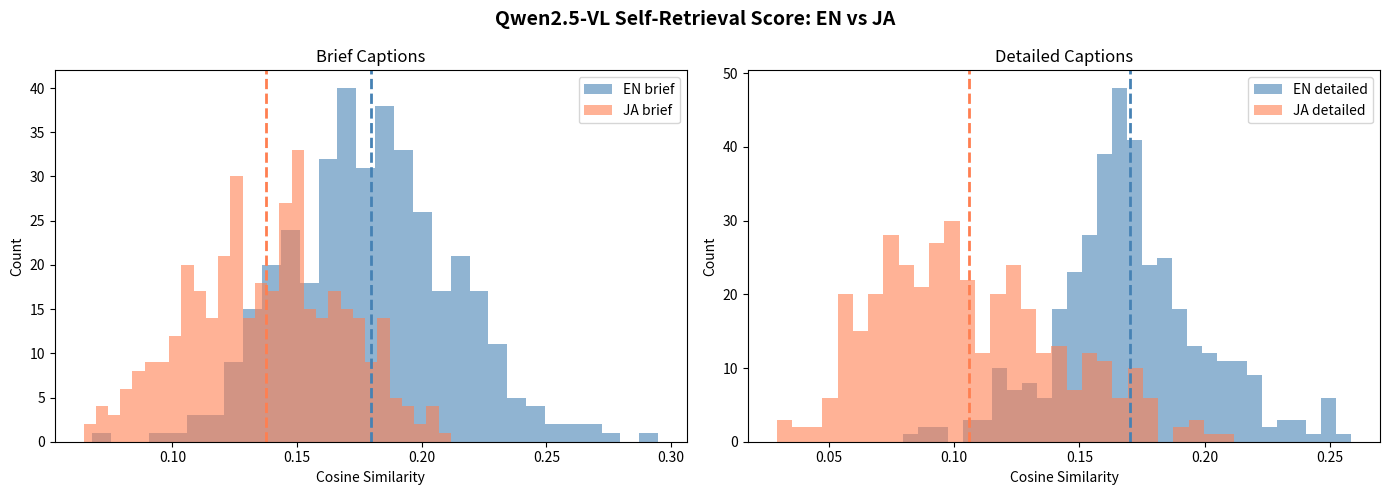

Saved: data/74_qwen_self_retrieval_en_vs_ja.png


In [18]:
# Self-Retrieval Score: EN vs JA 比較
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Brief
ax = axes[0]
ax.hist(self_retrieval['en_brief'], bins=30, alpha=0.6, label='EN brief', color='steelblue')
ax.hist(self_retrieval['ja_brief'], bins=30, alpha=0.6, label='JA brief', color='coral')
ax.axvline(self_retrieval['en_brief'].mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(self_retrieval['ja_brief'].mean(), color='coral', linestyle='--', linewidth=2)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('Brief Captions')
ax.legend()

# Detailed
ax = axes[1]
ax.hist(self_retrieval['en_detailed'], bins=30, alpha=0.6, label='EN detailed', color='steelblue')
ax.hist(self_retrieval['ja_detailed'], bins=30, alpha=0.6, label='JA detailed', color='coral')
ax.axvline(self_retrieval['en_detailed'].mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(self_retrieval['ja_detailed'].mean(), color='coral', linestyle='--', linewidth=2)
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('Detailed Captions')
ax.legend()

plt.suptitle('Qwen2.5-VL Self-Retrieval Score: EN vs JA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../data/74_qwen_self_retrieval_en_vs_ja.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/74_qwen_self_retrieval_en_vs_ja.png")

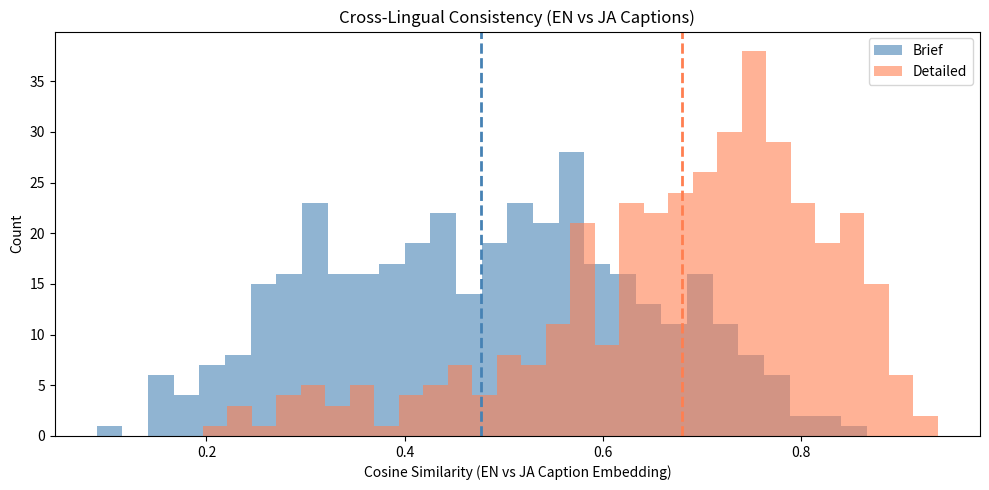

Saved: data/74_qwen_cross_lingual_consistency.png


In [19]:
# クロスリンガル一貫性の分布
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(cross_lingual_brief, bins=30, alpha=0.6, label='Brief', color='steelblue')
ax.hist(cross_lingual_detailed, bins=30, alpha=0.6, label='Detailed', color='coral')
ax.axvline(cross_lingual_brief.mean(), color='steelblue', linestyle='--', linewidth=2)
ax.axvline(cross_lingual_detailed.mean(), color='coral', linestyle='--', linewidth=2)
ax.set_xlabel('Cosine Similarity (EN vs JA Caption Embedding)')
ax.set_ylabel('Count')
ax.set_title('Cross-Lingual Consistency (EN vs JA Captions)')
ax.legend()

plt.tight_layout()
plt.savefig('../data/74_qwen_cross_lingual_consistency.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/74_qwen_cross_lingual_consistency.png")

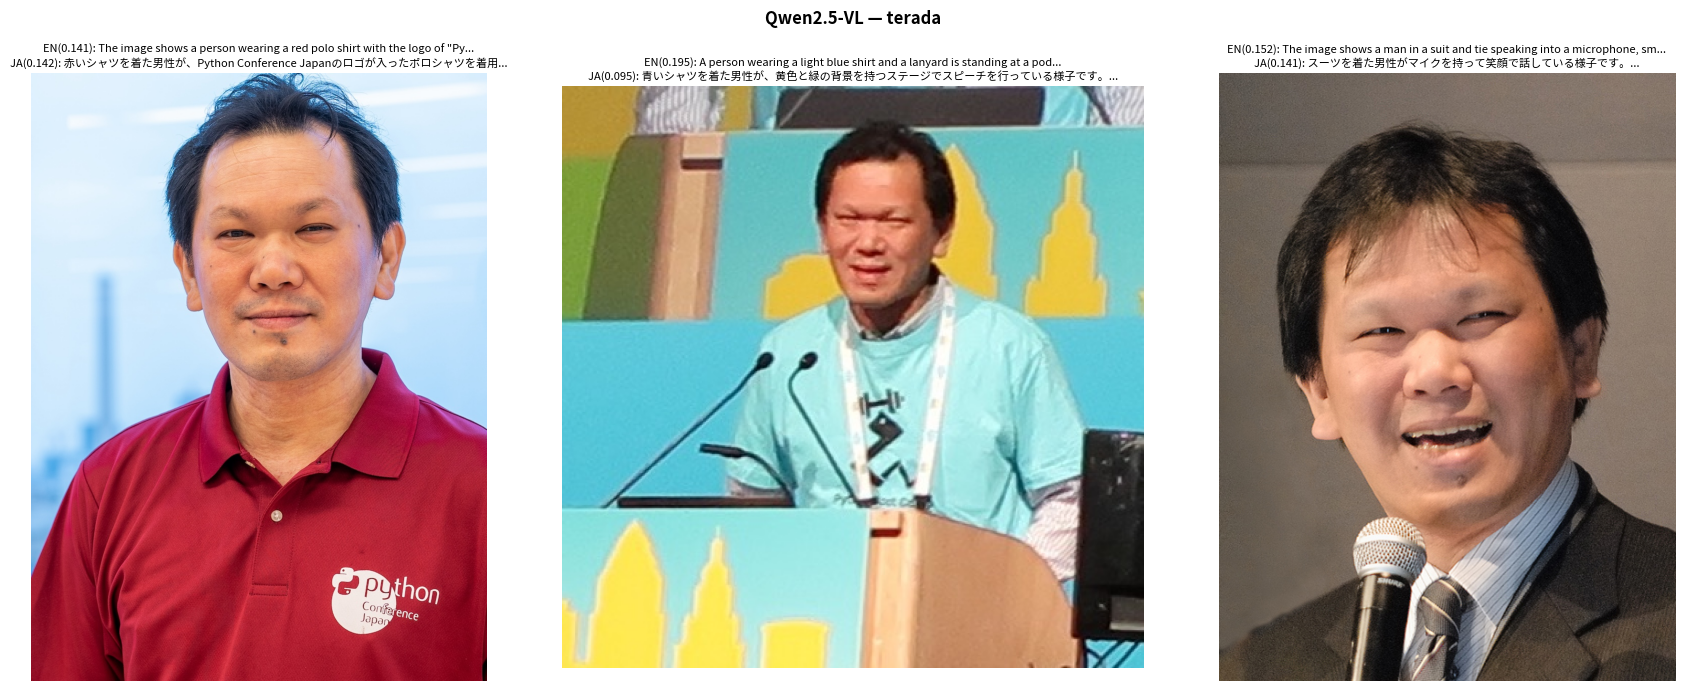

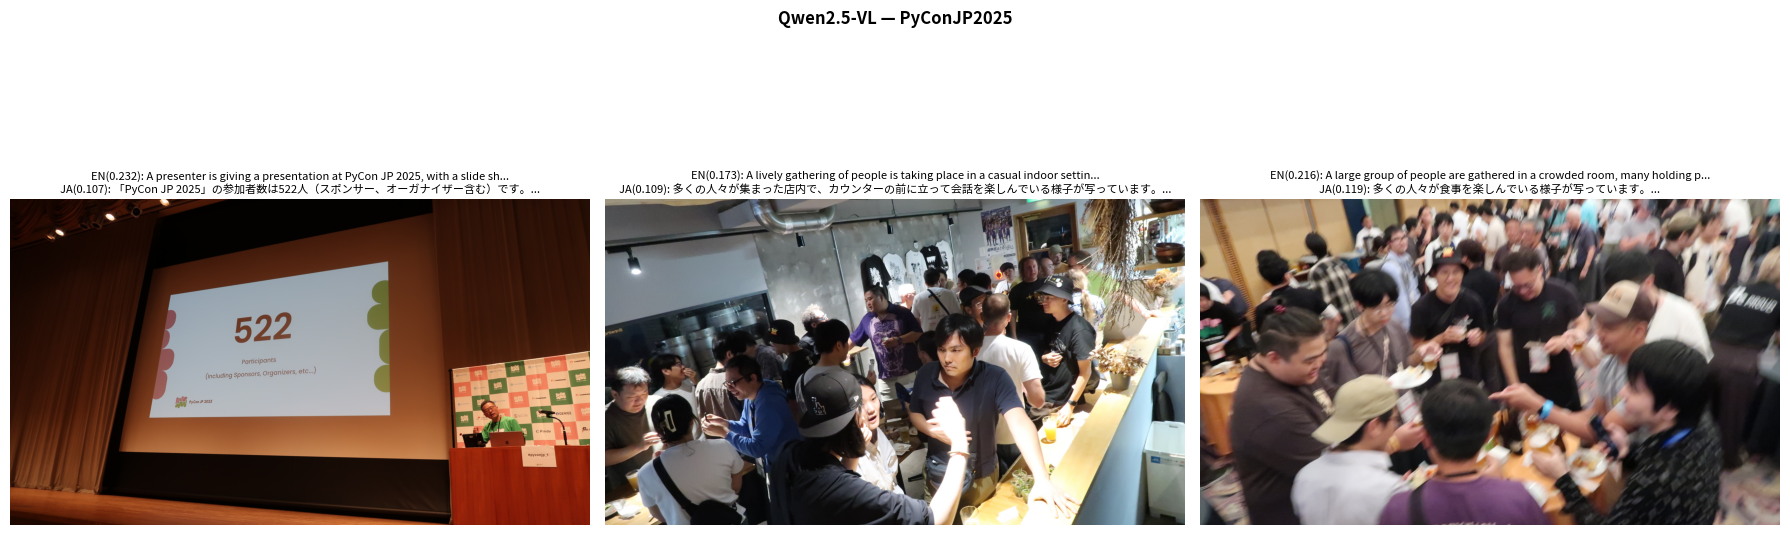

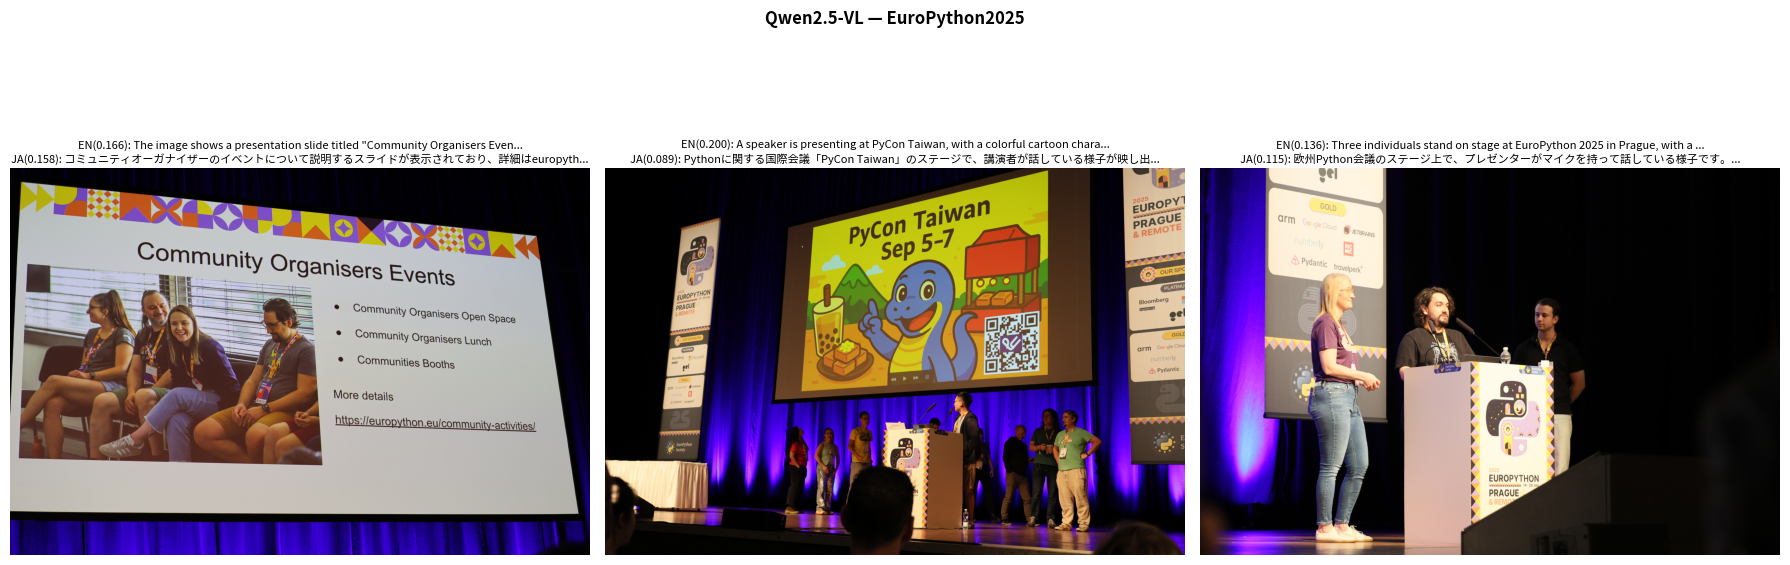

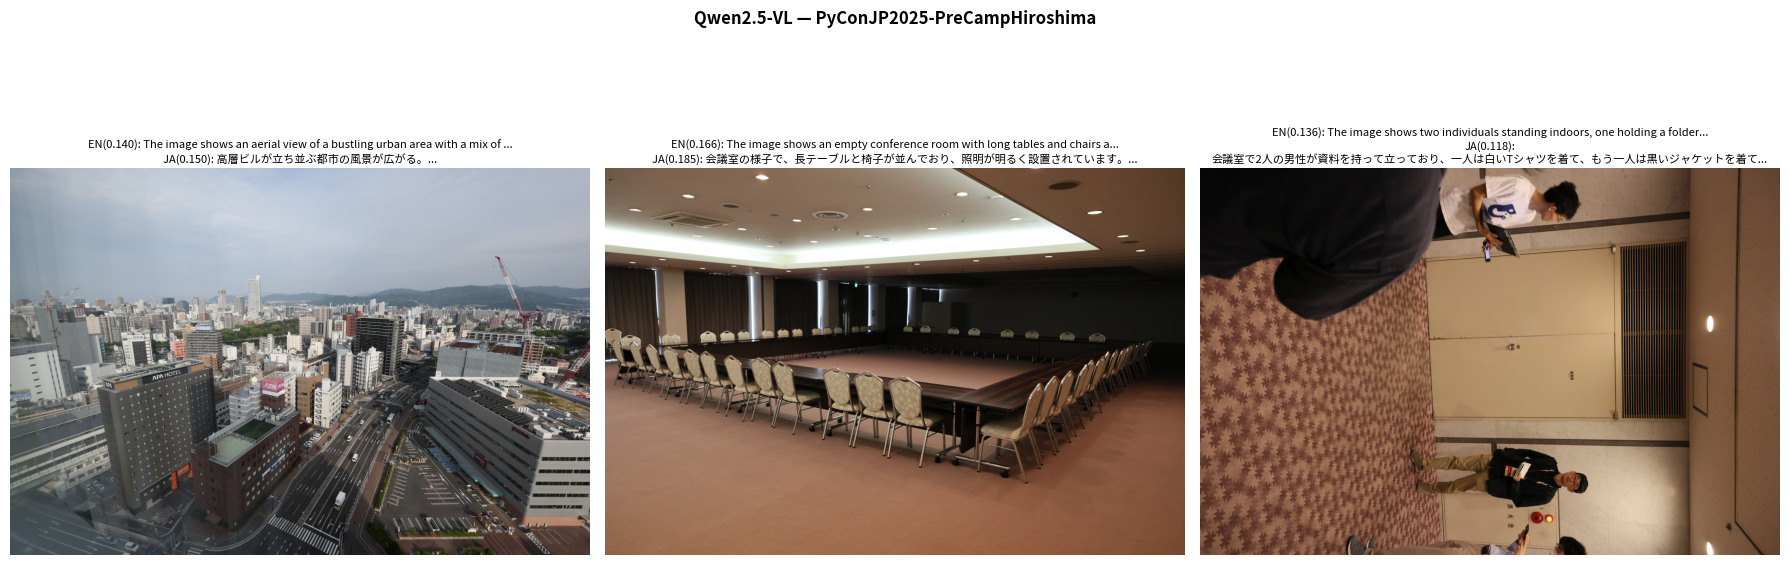

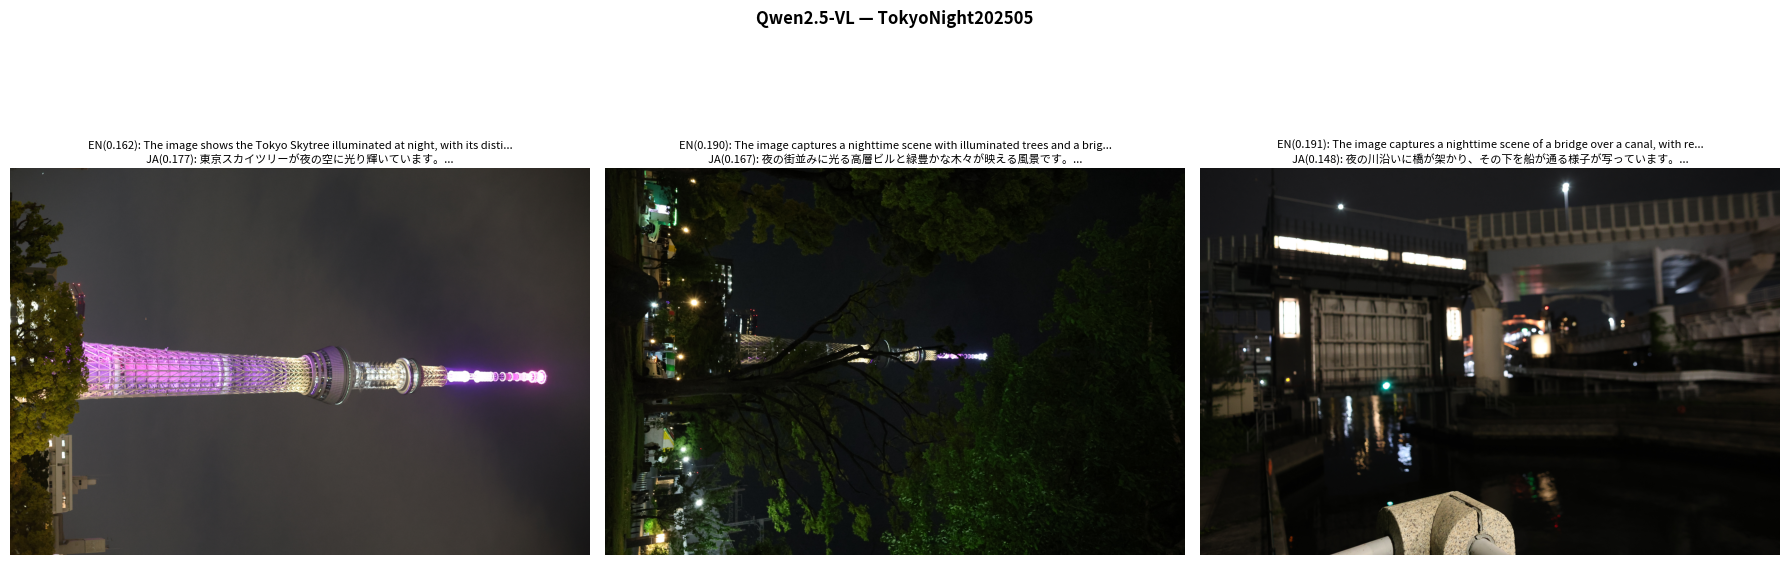

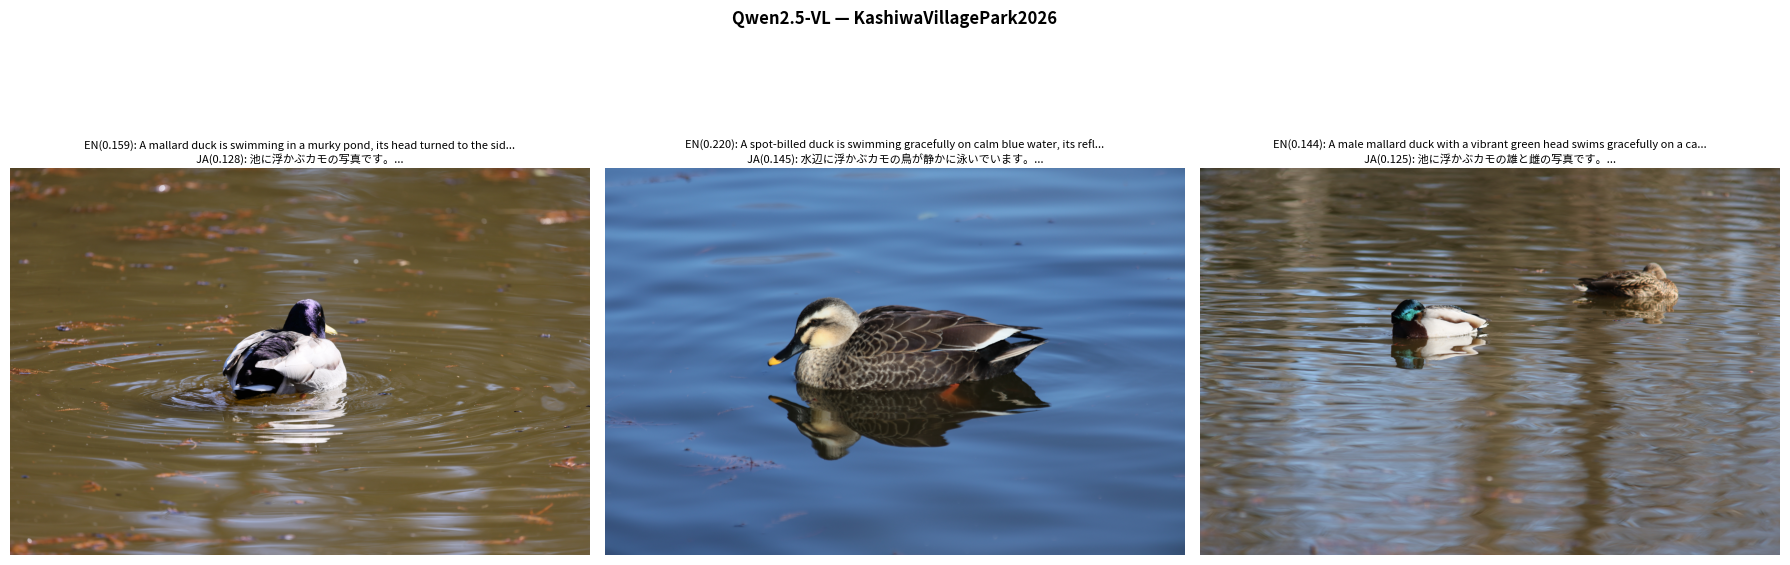

In [20]:
# 画像とキャプションの視覚的確認（日英並列）
for cat in catalog_df['category'].unique():
    cat_indices = catalog_df[catalog_df['category'] == cat].index.tolist()[:3]
    
    fig, axes = plt.subplots(1, len(cat_indices), figsize=(6 * len(cat_indices), 7))
    if len(cat_indices) == 1:
        axes = [axes]
    
    for i, idx in enumerate(cat_indices):
        row = catalog_df.iloc[idx]
        try:
            img = Image.open(row['file_path'])
            axes[i].imshow(img)
        except Exception:
            axes[i].text(0.5, 0.5, 'Image not found', ha='center', va='center')
        
        en_cap = all_captions['en_brief'][idx][:70]
        ja_cap = all_captions['ja_brief'][idx][:50]
        sr_en = self_retrieval['en_brief'][idx]
        sr_ja = self_retrieval['ja_brief'][idx]
        
        title = f"EN({sr_en:.3f}): {en_cap}...\nJA({sr_ja:.3f}): {ja_cap}..."
        axes[i].set_title(title, fontsize=8, wrap=True)
        axes[i].axis('off')
    
    plt.suptitle(f'Qwen2.5-VL — {cat}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

## 11. DuckDB にキャプションを保存

In [21]:
conn = duckdb.connect(str(DB_PATH))

conn.execute("""
    CREATE TABLE IF NOT EXISTS image_captions (
        image_id VARCHAR,
        model_name VARCHAR,
        caption_en TEXT,
        caption_ja TEXT,
        prompt_template VARCHAR,
        timestamp TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        PRIMARY KEY (image_id, model_name, prompt_template)
    )
""")

conn.execute("DELETE FROM image_captions WHERE model_name = ?", [QWEN_MODEL])

# brief キャプション（日英）を保存
for idx in range(len(catalog_df)):
    image_id = catalog_df.iloc[idx]['id']
    caption_en = all_captions['en_brief'][idx]
    caption_ja = all_captions['ja_brief'][idx]
    
    conn.execute("""
        INSERT INTO image_captions (image_id, model_name, caption_en, caption_ja, prompt_template)
        VALUES (?, ?, ?, ?, 'brief')
    """, [image_id, QWEN_MODEL, caption_en, caption_ja])

# detailed キャプション（日英）も保存
for idx in range(len(catalog_df)):
    image_id = catalog_df.iloc[idx]['id']
    caption_en = all_captions['en_detailed'][idx]
    caption_ja = all_captions['ja_detailed'][idx]
    
    conn.execute("""
        INSERT INTO image_captions (image_id, model_name, caption_en, caption_ja, prompt_template)
        VALUES (?, ?, ?, ?, 'detailed')
    """, [image_id, QWEN_MODEL, caption_en, caption_ja])

conn.commit()

count = conn.execute(
    "SELECT COUNT(*) FROM image_captions WHERE model_name = ?", [QWEN_MODEL]
).fetchone()[0]
print(f"Stored {count} captions for model '{QWEN_MODEL}'")

all_counts = conn.execute(
    "SELECT model_name, COUNT(*) FROM image_captions GROUP BY model_name"
).fetchall()
print("\nAll models in image_captions:")
for m, c in all_counts:
    print(f"  {m}: {c}")

conn.close()

Stored 756 captions for model 'Qwen/Qwen2.5-VL-7B-Instruct'

All models in image_captions:
  Salesforce/blip2-opt-2.7b: 378
  Qwen/Qwen2.5-VL-7B-Instruct: 756


## 12. 結果の保存

In [22]:
output_data = {
    "notebook": "74-qwen25vl-captioning",
    "model_name": QWEN_MODEL,
    "eval_model": SIGLIP2_MODEL,
    "timestamp": datetime.now().isoformat(),
    "total_images": len(catalog_df),
    "self_retrieval": {
        key: {
            "mean": float(self_retrieval[key].mean()),
            "std": float(self_retrieval[key].std()),
        }
        for key in prompt_configs
    },
    "cross_lingual_consistency": {
        "brief": {"mean": float(cross_lingual_brief.mean()), "std": float(cross_lingual_brief.std())},
        "detailed": {"mean": float(cross_lingual_detailed.mean()), "std": float(cross_lingual_detailed.std())},
    },
    "clip_scores": {
        key: {"mean": float(clip_scores[key].mean()), "std": float(clip_scores[key].std())}
        for key in clip_scores
    } if clip_scores else {},
    "retrieval_rank": {
        key: {
            "mean_rank": float(retrieval_results[key].mean()),
            "mrr": float((1.0 / retrieval_results[key]).mean()),
            "rank_at_1_ratio": float((retrieval_results[key] == 1).mean()),
        }
        for key in retrieval_results
    },
    "processing_time_seconds": elapsed,
}

output_path = Path("../data/evaluations") / f"74_qwen25vl_captioning_{datetime.now().strftime('%Y-%m-%d')}.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, ensure_ascii=False)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/74_qwen25vl_captioning_2026-02-19.json


## 13. GPU メモリのクリーンアップ

In [23]:
del embedder

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

GPU memory cleared.


## まとめ・評価・考察

Qwen2.5-VL-7B-Instruct で初めて日英バイリンガルの画像キャプションを生成し、
前のノートブック（BLIP-2）と比較した。

### 実験結果

| モデル/モード | SR | Retrieval MRR | Rank@1 | JA対応 | VRAM |
|--------|:---:|:---:|:---:|:---:|:---:|
| NB71 Tag-based (EN) | 0.1268 | — | — | Limited | ~3GB |
| NB71 Pool-based (EN) | 0.1070 | 0.1102 | 3.7% | Limited | ~3GB |
| NB72 BLIP-2 (brief) | 0.1610 | 0.4352 | 27.2% | No | ~6GB |
| **NB74 Qwen2.5-VL (EN brief)** | **0.1797** | **0.6350** | **50.5%** | **Yes** | ~15GB |
| NB74 Qwen2.5-VL (EN detailed) | 0.1701 | 0.4660 | 32.0% | Yes | ~15GB |
| NB74 Qwen2.5-VL (JA brief) | 0.1375 | 0.3176 | 19.0% | Yes | ~15GB |
| NB74 Qwen2.5-VL (JA detailed) | 0.1058 | 0.2435 | 13.2% | Yes | ~15GB |

### BLIP-2 との比較

- **Self-Retrieval Score**: EN brief で **+0.019**（0.161 → 0.180、12%向上）
- **Retrieval MRR**: EN brief で **+0.200**（0.435 → 0.635、46%向上）
- **Rank@1**: **+23.3pt**（27.2% → 50.5%）

Qwen2.5-VL は BLIP-2 を全指標で大幅に上回った。7Bパラメータの VLM は、Q-Former ベースの BLIP-2 より遥かに高品質なキャプションを生成する。

### プロンプト別分析

- **brief > detailed**: EN/JA ともに brief モードが superior。
  - brief: 簡潔な一文→embedding空間での表現が凝縮される
  - detailed: 長文→情報が分散し、embeddingの焦点がぼやける
- **EN > JA**: SR/MRR ともに英語が日本語を上回る。
  - SigLIP 2 Large の評価モデルが英語に最適化されている影響
  - Qwen2.5-VL の日本語生成品質自体は高いが、embedding空間での表現力に差がある

### クロスリンガル一貫性

- **brief**: EN-JA 間の embedding 類似度 平均 **0.477**
- **detailed**: EN-JA 間の embedding 類似度 平均 **0.680**
- detailed の方がクロスリンガル一貫性が高い。長文は言語間で共通する意味的内容が多いため。
- brief は言語ごとの表現の違い（文構造、省略の差等）がembeddingに反映されやすい。

### CLIPScore による独立検証

- CLIPScore (CLIP-L): EN brief **0.285**, JA brief **0.216**
- SigLIP 2 の Self-Retrieval Score と同じ傾向（EN > JA）を示し、評価の妥当性を確認。

### 処理時間

- **11,689秒**（約3時間15分）、378画像 × 4プロンプト
- 約 **7.7秒/画像**（全プロンプト含む）
- BLIP-2 の 1.15秒/画像 に比べ約6.7倍遅い。7B VLM のコスト。

### 考察

1. **Qwen2.5-VL の強み**
   - 初めて高品質な日本語キャプションを生成。日本語固有の表現（「カンファレンスの講演」「公園の遊歩道」等）を適切に生成。
   - EN Retrieval MRR 0.635 は、キャプションで元画像を半数以上1位で検索できることを意味し、キャプション品質の高さを実証。

2. **日本語キャプションの課題**
   - JA MRR (0.318) は EN MRR (0.635) の約半分。
   - これは Qwen2.5-VL の日本語品質ではなく、**SigLIP 2 Large の日本語テキスト embedding 精度**の限界を反映。
   - SigLIP 2 は Gemma BPE トークナイザーで日本語を扱えるが、英語ほどの精度は出ない。

3. **次のステップ**
   - Notebook 75: InternVL2.5-8B で2つ目のVLMを評価し、Qwen2.5-VL との比較。
   - Notebook 76: 生成キャプションを使った検索パイプラインの構築。